In [1]:
	
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling import models, fitting
fitter = fitting.LinearLSQFitter()
from scipy.ndimage import median_filter
from tqdm import tqdm
from random import gauss

In [2]:
Oct2015='../Spectra/B103/FEROS_2015OCT/ADP.2016-09-28T06:54:52.145.fits'
Dec2015='../Spectra/B103/FEROS_2015DEC/ADP.2016-09-28T06:54:49.594.fits'
Jul2016='../Spectra/B103/FEROS_2016JUL/ADP.2016-09-28T11:26:18.933.fits'
fits.open(Oct2015)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1168401a0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x116841400>]

In [3]:
#fits.getheader(Oct2015)

In [4]:
data1=fits.getdata(Oct2015)
data2=fits.getdata(Dec2015)
data3=fits.getdata(Jul2016)
data3

FITS_rec([([3527.51999997, 3527.54999997, 3527.57999997, ..., 9216.6898728 , 9216.7198728 , 9216.7498728 ], [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,  1.71294913e-03,  6.24866807e-04,  0.00000000e+00], [nan, nan, nan, ..., nan, nan, nan])],
         dtype=(numpy.record, [('WAVE', '>f8', (189642,)), ('FLUX', '>f4', (189642,)), ('ERR', '>f4', (189642,))]))

In [33]:
#Data October 2015
xd1_new=data1['FLUX'][0].tolist()
xd1_filt=median_filter(xd1_new,20)
lam1 = data1['WAVE'][0]

mask_alpha1=np.abs(6562.8-lam1)>40
mask_beta1=np.abs(4861.33333333333-lam1)>40
mask_gamma1=np.abs(4367.23-lam1)>50 #H_gamma está corrido
mask1=mask_alpha1&mask_beta1&mask_gamma1

#Data December 2015
xd2_new=data2['FLUX'][0].tolist()
xd2_filt=median_filter(xd2_new,20)
lam2 = data2['WAVE'][0]

mask_alpha2=np.abs(6562.8-lam2)>40
mask_beta2=np.abs(4861.33333333333-lam2)>40
mask_gamma2=np.abs(4367.23-lam2)>50 #H_gamma está corrido
mask2=mask_alpha2&mask_beta2&mask_gamma2

#Data July 2016
xd3_new=data3['FLUX'][0].tolist()
xd3_filt=median_filter(xd3_new,20)
lam3 = data3['WAVE'][0]

mask_alpha3=np.abs(6562.8-lam3)>40
mask_beta3=np.abs(4861.33333333333-lam3)>40
mask_gamma3=np.abs(4367.23-lam3)>50 #H_gamma está corrido
mask3=mask_alpha3&mask_beta3&mask_gamma3

In [34]:
modelo1 = fitter(models.Chebyshev1D(25),lam1[mask1],xd1_filt[mask1])
modelo2 = fitter(models.Chebyshev1D(25),lam2[mask2],xd2_filt[mask2])
modelo3 = fitter(models.Chebyshev1D(25),lam3[mask3],xd3_filt[mask3])


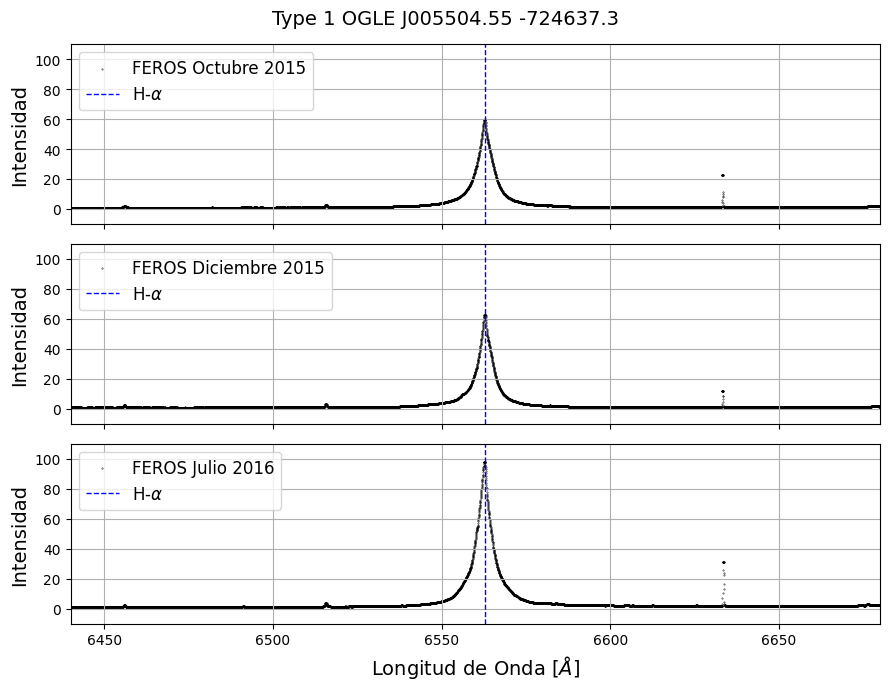

In [35]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(9, 7))  # 5 rows, 1 column

# Plot each light curve
axs[0].scatter(lam1-3.5,xd1_filt/modelo1(lam1),s=0.1, color='black', label='FEROS Octubre 2015')
axs[1].scatter(lam2-3.5,xd2_filt/modelo2(lam2), s=0.1, color='black',label='FEROS Diciembre 2015')
axs[2].scatter(lam3-3.5,xd3_filt/modelo3(lam3), s=0.1, color='black',label='FEROS Julio 2016')



# Labels
for ax in axs:
    ax.set_ylabel('Intensidad',fontsize=14) 
    ax.axvline(x=6562.8, color='blue', linestyle='--', linewidth=1,label=r'H-$\alpha$')
    ax.axvline(x=4861.3, color='blue', linestyle='--', linewidth=1)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True)
axs[-1].set_xlabel(r'Longitud de Onda [$\AA$]',fontsize=14)
axs[-1].set_xlim(6440, 6680)
#axs[-1].set_xlim(4740, 4980)#H-beta
axs[0].set_ylim(-10, 110)
axs[1].set_ylim(-10, 110)
axs[2].set_ylim(-10,110)

fig.suptitle('Type 1 OGLE J005504.55 -724637.3',fontsize=14)
plt.tight_layout()
plt.savefig('B103')
plt.show()

In [36]:
wb= 10 #Ancho banda azul
cb= 6530 #Posición banda azul
cr= 6590 #Posición roja
wr= 10 #Ancho banda roja
wf= 30 #Ancho banda emisión
cf = 6562.8 #Posición banda emisión
n_iter = 100

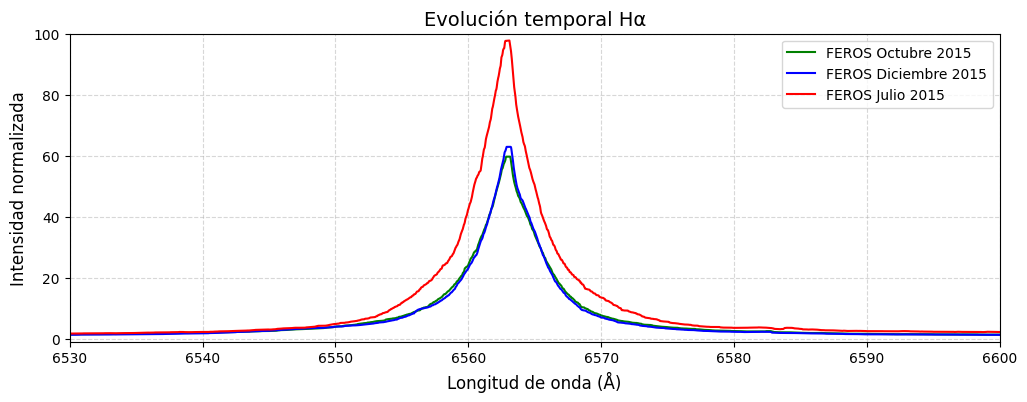

In [42]:
EW_sst = []
#with fits.open(Oct2015) as hdul:
h1 = fits.getheader(Oct2015)                            
fl = (xd1_filt/modelo1(lam1))[98900:-86000] #Flux normalizado
efl = data1['ERR'][0]
wl = (lam1-3.3)[98900:-86000] #wavelength

plt.figure(figsize=(12,4))
        
plt.plot(wl, fl,color='green',label='FEROS Octubre 2015')
plt.plot((lam2-3.3),(xd2_filt/modelo2(lam2)),color='blue',label='FEROS Diciembre 2015')
plt.plot((lam3-3.3),(xd3_filt/modelo3(lam3)),color='red', label='FEROS Julio 2015')

#plt.axvline(x=6562.8, color='blue', linestyle='--', linewidth=1,label=r'H-$\alpha$')
#plt.axvline(x=6545.6, color='red', linestyle='--', linewidth=1)
#plt.axvline(x=6575.6, color='red', linestyle='--', linewidth=1)

plt.xlabel('Longitud de onda (Å)', fontsize=12)
plt.ylabel('Intensidad normalizada', fontsize=12)
plt.title('Evolución temporal Hα', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlim(6530,6600)
plt.ylim(-1,100)

SampleEW = []
        

In [13]:
def EW (wl, fl, cf, wf, cb, wb, cr, wr, n_iter):
    
    ratc = (cf-cb)/(cr-cb) #Término denominador de la ecuación de Hernandez et al.
    EWs = []
    
    for n in range(n_iter):

        #Formar banda emisión
        whf = np.where([(wl>cf-wf/2) & (wl<cf+wf/2)])[1]
        yf = [gauss(i, np.sqrt(i)) for i in fl[whf]]
        #np.abs(i)

        #Formar banda azul
        whb = np.where([(wl> cb-wb/2) & (wl< cb+wb/2)])[1]
        yb = [gauss(i, np.sqrt(i)) for i in fl[whb]]

        #Formar banda roja
        whr = np.where([(wl> cr-wr/2) & (wl< cr+wr/2)])[1]
        yr = [gauss(i, np.sqrt(i)) for i in fl[whr]]

        if np.isnan(yf).any() or np.isnan(yb).any() or np.isnan(yr).any():
            continue
        
        else:
        
            Ff = np.mean(yf)
            Fb = np.mean(yb)
            Fr = np.mean(yr)

            EWi = - wf * (1 - (Ff / ( Fb + ratc*(Fr - Fb))))

        EWs.append(EWi)

    EW = np.mean(np.array(EWs)[~np.isnan(EWs)])
    sEW = np.std(np.array(EWs)[~np.isnan(EWs)])
    return EW,sEW

In [20]:
EWmeOct2015 = EW(wl, fl, cf, wf, cb, wb, cr, wr, n_iter)
EWmeOct2015

(253.27542681155683, 8.478786990464137)

In [23]:
EWmeDic2015 = EW((lam2-3.5)[98900:-86000], (xd2_filt/modelo2(lam2))[98900:-86000], cf, wf, cb, wb, cr, wr, n_iter)
EWmeDic2015

(273.46115010025443, 9.570604903885286)

In [24]:
EWmeOct2015 = EW((lam3-3.5)[98900:-86000], (xd3_filt/modelo3(lam3))[98900:-86000], cf, wf, cb, wb, cr, wr, n_iter)
EWmeOct2015

(291.5699868996165, 9.062114079126662)

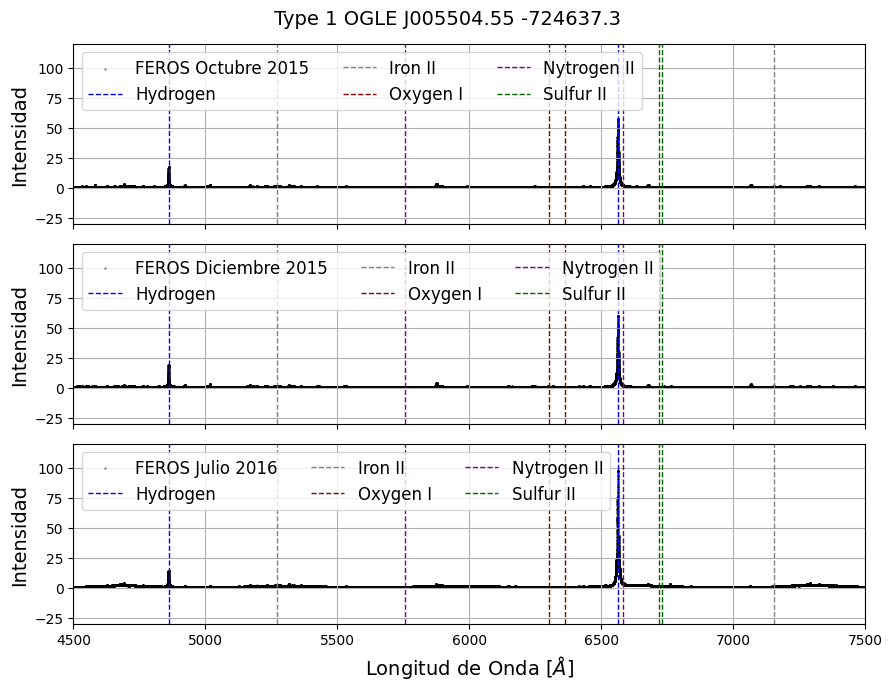

In [18]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(9, 7))  # 5 rows, 1 column

# Plot each light curve
axs[0].scatter(lam1-3.6,xd1_filt/modelo1(lam1),s=0.1, color='black', label='FEROS Octubre 2015')
axs[1].scatter(lam2-3.6,xd2_filt/modelo2(lam2), s=0.1, color='black',label='FEROS Diciembre 2015')
axs[2].scatter(lam3-3.6,xd3_filt/modelo3(lam3), s=0.1, color='black',label='FEROS Julio 2016')



# Labels
for ax in axs:
    ax.set_ylabel('Intensidad',fontsize=14) 
    ax.axvline(x=6562.8, color='blue', linestyle='--', linewidth=1,label=r'Hydrogen')
    ax.axvline(x=4861.3, color='blue', linestyle='--', linewidth=1)
    ax.axvline(x=7155, color='gray', linestyle='--', linewidth=1,label=r'Iron II')
    ax.axvline(x=4244, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=4287, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=4415, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=5273, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=6300, color='darkred', linestyle='--', linewidth=1,label=r'Oxygen I')
    ax.axvline(x=6363, color='darkred', linestyle='--', linewidth=1)
    ax.axvline(x=5755, color='purple', linestyle='--', linewidth=1,label=r'Nytrogen II')
    ax.axvline(x=6584, color='purple', linestyle='--', linewidth=1)
    ax.axvline(x=4068, color='darkgreen', linestyle='--', linewidth=1,label=r'Sulfur II')
    ax.axvline(x=6717, color='darkgreen', linestyle='--', linewidth=1)
    ax.axvline(x=6730, color='darkgreen', linestyle='--', linewidth=1)
    ax.legend(loc='upper left', fontsize=12,ncol=3)
    ax.grid(True)
axs[-1].set_xlabel(r'Longitud de Onda [$\AA$]',fontsize=14)
axs[-1].set_xlim(4500, 7500)
axs[0].set_ylim(-30, 120)
axs[1].set_ylim(-30, 120)
axs[2].set_ylim(-30,120)

fig.suptitle('Type 1 OGLE J005504.55 -724637.3',fontsize=14)
plt.tight_layout()
plt.savefig('B103_full')
plt.show()